# UW DRP 2026S Pairs Trading Project

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import datetime as dt 
import talib as ta

In [25]:
# Mock data
mock_ticker = yf.Ticker('SPY')
mock_start_date = dt.datetime.now() - dt.timedelta(days=8*365) # 8 yrs from today
mock_data = mock_ticker.history(start=mock_start_date)

In [26]:
mock_data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2018-07-30 00:00:00-04:00,249.242852,249.402213,247.339267,247.861664,63742500,0.0,0.0,0.0
2018-07-31 00:00:00-04:00,248.622972,249.694272,248.242266,249.083359,68570500,0.0,0.0,0.0
2018-08-01 00:00:00-04:00,249.287073,249.791745,248.020989,248.667297,53853300,0.0,0.0,0.0
2018-08-02 00:00:00-04:00,247.365823,250.190154,247.162176,250.021957,63426400,0.0,0.0,0.0
2018-08-03 00:00:00-04:00,250.145961,251.146443,249.968875,251.093323,53935400,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
2026-07-22 00:00:00-04:00,746.619995,750.020020,746.369995,747.409973,32836200,0.0,0.0,0.0
2026-07-23 00:00:00-04:00,739.369995,742.559998,735.210022,738.179993,55437300,0.0,0.0,0.0
2026-07-24 00:00:00-04:00,738.510010,743.719971,737.289978,738.929993,44782000,0.0,0.0,0.0


In [27]:
mock_data['RSI'] = ta.RSI(mock_data['Close'], timeperiod=14)
mock_buy_signals = mock_data[mock_data['RSI'] <= 30]
mock_sell_signals = mock_data[mock_data['RSI'] >= 70]

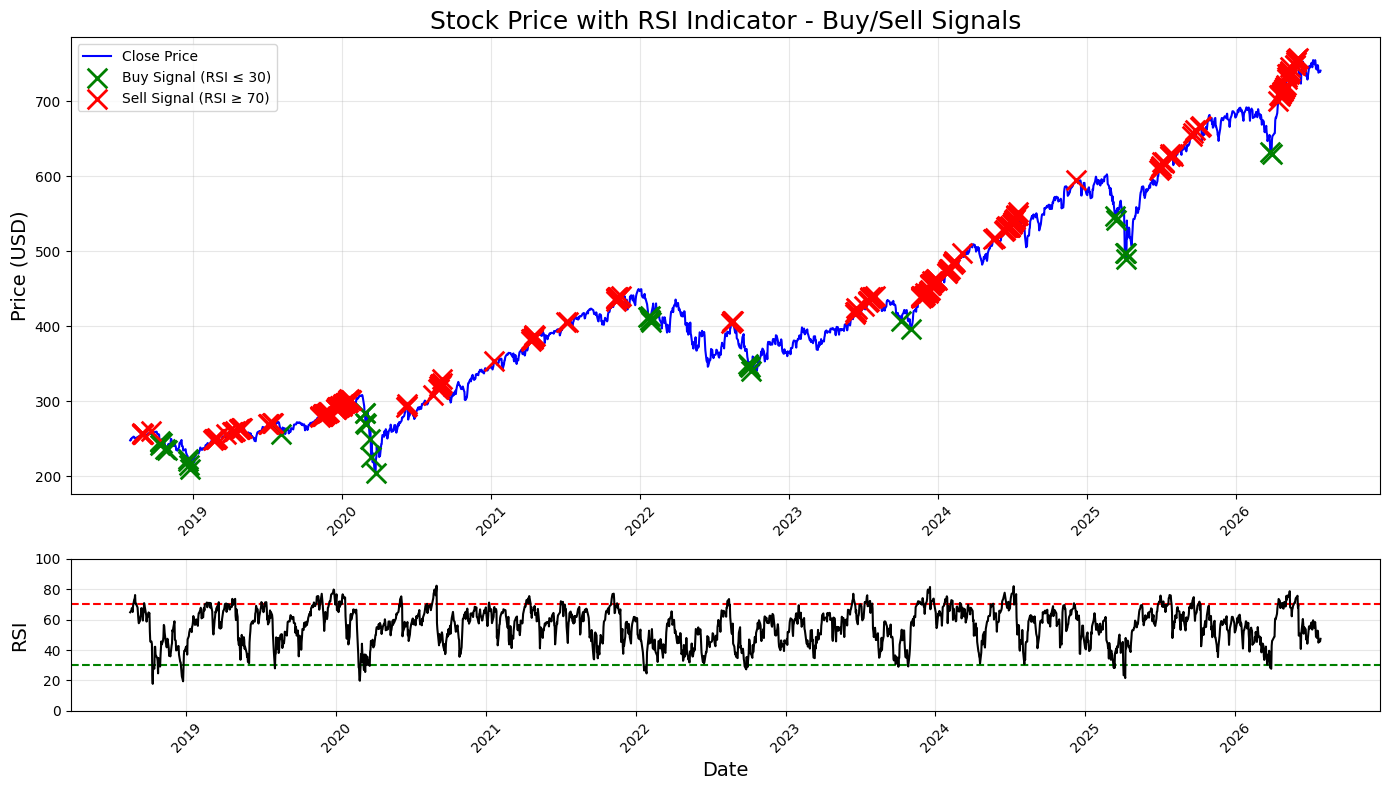

In [28]:
fig, ax = plt.subplots(2, 1, gridspec_kw={"height_ratios": [3, 1]}, figsize=(14, 8))

# Top subplot: Close Price
ax[0].plot(mock_data['Close'], label='Close Price', linewidth=1.5, color='blue')

# Add buy signals (green X)
ax[0].scatter(mock_buy_signals.index, mock_buy_signals['Close'], marker='x', color='green', 
              s=200, linewidths=2, label='Buy Signal (RSI ≤ 30)', zorder=5)

# Add sell signals (red X)
ax[0].scatter(mock_sell_signals.index, mock_sell_signals['Close'], marker='x', color='red', 
              s=200, linewidths=2, label='Sell Signal (RSI ≥ 70)', zorder=5)

ax[0].set_title('Stock Price with RSI Indicator - Buy/Sell Signals', fontsize=18)
ax[0].set_ylabel('Price (USD)', fontsize=14)
ax[0].legend(fontsize=10, loc='upper left')
ax[0].grid(True, alpha=0.3)



# Bottom subplot: RSI
ax[1].axhline(y=70, color='red', ls='dashed', linewidth=1.5, label='Overbought (70)')
ax[1].axhline(y=30, color='green', ls='dashed', linewidth=1.5, label='Oversold (30)')
ax[1].plot(mock_data['RSI'], color='black', linewidth=1.5, label='RSI (14)')
ax[1].set_ylabel('RSI', fontsize=14)
ax[1].set_xlabel('Date', fontsize=14)
ax[1].set_ylim([0, 100])
#ax[1].legend(fontsize=10, loc='upper left')
ax[1].grid(True, alpha=0.3)

# Rotate x-axis labels for both subplots
plt.setp(ax[0].xaxis.get_majorticklabels(), rotation=45)
plt.setp(ax[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()

# 1. Pairs Statistics & Selection

This section implements the first phase of pairs trading: data acquisition, cleaning, cointegration testing, spread estimation, and z-score calculation, producing `build_pairs_table` for later signal generation.

Pipeline: `download_adjusted_close` → `clean_price_data` → `test_cointegration` → `compute_hedge_ratio` → `compute_spread` → `compute_zscore` → `build_pairs_table`

`DEFAULT_PAIRS` is a placeholder list — replace with the team's final pair selections after cointegration testing.

`build_pairs_table` is the primary output of Section 1 — schema: `date, pair, asset_1, asset_2, alpha, beta, spread, z_score`


In [29]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
from itertools import combinations

#   KO-PEP    Coca-Cola vs PepsiCo (beverages)
#   MA-V      Mastercard vs Visa (payments)
#   XOM-CVX   ExxonMobil vs Chevron (energy/oil)
#   TD-RY     TD Bank vs Royal Bank of Canada (Canadian banking)
#   SPY-QQQ   S&P 500 ETF vs Nasdaq-100 ETF (broad market indices)
DEFAULT_PAIRS = [("MA", "V")]
BENCHMARK_TICKER = "SPY"

# Flatten DEFAULT_PAIRS, add the benchmark, deduplicate, sort — produces the full ticker list needed for the price download
ALL_TICKERS = sorted({ticker for pair in DEFAULT_PAIRS for ticker in pair} | {BENCHMARK_TICKER})
ALL_TICKERS

['CVX', 'KO', 'MA', 'PEP', 'QQQ', 'RY', 'SPY', 'TD', 'V', 'XOM']

In [30]:
def download_adjusted_close(tickers, start, end):
    if isinstance(tickers, str):
        tickers = [tickers]

    raw = yf.download(tickers, start=start, end=end, auto_adjust=True)
    prices = raw["Close"]

    if isinstance(prices, pd.Series):
        prices = prices.to_frame(name=tickers[0])

    return prices

In [31]:
# Date range aligned with the project spec (2018-2026); end = today to get the most recent data
START_DATE = "2018-01-01"
END_DATE = dt.date.today().isoformat()

raw_prices = download_adjusted_close(ALL_TICKERS, START_DATE, END_DATE)
raw_prices.tail()

[*********************100%***********************]  10 of 10 completed


Ticker,CVX,KO,MA,PEP,QQQ,RY,SPY,TD,V,XOM
2026-07-21,191.070007,81.970001,538.299988,135.000000,708.969971,209.620316,748.280029,120.529999,355.820007,151.710007
2026-07-22,192.979996,82.199997,531.979980,135.649994,705.349976,210.186890,747.409973,121.300003,353.420013,154.449997
2026-07-23,194.419998,81.169998,530.289978,134.949997,691.960022,207.214767,738.179993,119.220001,351.600006,156.889999
2026-07-24,194.789993,82.250000,539.659973,136.639999,684.229980,207.840988,738.929993,119.779999,355.739990,156.940002
2026-07-27,190.000000,84.070000,551.710022,139.789993,682.119995,209.509995,739.090027,119.650002,362.529999,154.770004


In [32]:
"""
    Clean missing values from price data so downstream return and correlation
    calculations don't fail or produce incorrect results due to NaNs.

    Args:
      prices: pd.DataFrame, output of download_adjusted_close (may contain NaNs)

    Returns:
      pd.DataFrame, same column structure, but:
        - all-NaN columns removed
        - rows trimmed to the common valid date range across all tickers
        - no NaNs
"""

def clean_price_data(prices):
    # 1) Drop entirely-NaN columns (failed downloads)
    cleaned = prices.dropna(axis=1, how="all")

    # 2) Forward-fill sporadic missing trading days
    cleaned = cleaned.ffill()

    # 3) Trim to the latest common start date across all tickers
    common_start = max(cleaned[col].first_valid_index() for col in cleaned.columns)
    cleaned = cleaned.loc[common_start:]

    # 4) Sanity check: no NaNs should remain after cleaning
    assert cleaned.isna().sum().sum() == 0, "NaNs still present after clean_price_data"

    return cleaned

In [33]:
prices = clean_price_data(raw_prices)
print(f"Clean date range: {prices.index.min().date()} ~ {prices.index.max().date()}, {len(prices)} trading days")
prices.tail()

Clean date range: 2018-01-02 ~ 2026-07-27, 2152 trading days


Ticker,CVX,KO,MA,PEP,QQQ,RY,SPY,TD,V,XOM
2026-07-21,191.070007,81.970001,538.299988,135.000000,708.969971,209.620316,748.280029,120.529999,355.820007,151.710007
2026-07-22,192.979996,82.199997,531.979980,135.649994,705.349976,210.186890,747.409973,121.300003,353.420013,154.449997
2026-07-23,194.419998,81.169998,530.289978,134.949997,691.960022,207.214767,738.179993,119.220001,351.600006,156.889999
2026-07-24,194.789993,82.250000,539.659973,136.639999,684.229980,207.840988,738.929993,119.779999,355.739990,156.940002
2026-07-27,190.000000,84.070000,551.710022,139.789993,682.119995,209.509995,739.090027,119.650002,362.529999,154.770004


In [34]:
"""
    Test whether a pair of price series is cointegrated using the Engle-Granger test.

    Args:
      prices: pd.DataFrame, cleaned prices
      pair: tuple[str, str]

    Returns:
      dict: {"pair": str, "p_value": float, "is_cointegrated": bool}
"""
def test_cointegration(prices, pair):
    asset_1, asset_2 = pair
    s1, s2 = prices[asset_1].dropna().align(prices[asset_2].dropna(), join="inner")
    _, p_value, _ = coint(s1, s2)
    return {
        "pair": f"{asset_1}-{asset_2}",
        "p_value": round(p_value, 4),
        "is_cointegrated": p_value < 0.05,
    }

In [35]:
# Run cointegration test for all 5 pairs and display results as a table
cointegration_results = pd.DataFrame([test_cointegration(prices, pair) for pair in DEFAULT_PAIRS])
cointegration_results

,pair,p_value,is_cointegrated
0,KO-PEP,1.0000,False
1,MA-V,0.0289,True
2,XOM-CVX,0.0781,False
3,TD-RY,0.6291,False
4,SPY-QQQ,0.1394,False


In [36]:
"""
    Estimate the hedge ratio via OLS regression of asset_1 price on asset_2 price.

    Args:
      prices: pd.DataFrame, cleaned prices
      pair: tuple[str, str]

    Returns:
      tuple[float, float]: (alpha, beta)
        alpha: OLS intercept
        beta:  OLS slope (hedge ratio)
"""

def compute_hedge_ratio(prices, pair):
    asset_1, asset_2 = pair
    s1, s2 = prices[asset_1].dropna().align(prices[asset_2].dropna(), join="inner")
    model = sm.OLS(s1, sm.add_constant(s2)).fit()
    alpha = float(model.params["const"])
    beta  = float(model.params[asset_2])
    return alpha, beta

In [37]:
"""
    Compute the spread (regression residual) between two assets.

    Formula: ε = P1 - (alpha + beta * P2)

    Args:
      prices: pd.DataFrame, cleaned prices
      pair: tuple[str, str]
      alpha: float, OLS intercept from compute_hedge_ratio
      beta:  float, OLS slope from compute_hedge_ratio

    Returns:
      pd.Series, index = Date, name = "ASSET1-ASSET2_spread"
"""

def compute_spread(prices, pair, alpha, beta):
    asset_1, asset_2 = pair
    spread = prices[asset_1] - (alpha + beta * prices[asset_2])
    spread.name = f"{asset_1}-{asset_2}_spread"
    return spread.dropna()

In [38]:
"""
    Compute the z-score of the spread.

    Args:
      spread: pd.Series, output of compute_spread
      window: int or None (default None = static over full history)

    Returns:
      pd.Series, z-score values (NaN rows dropped)
"""
def compute_zscore(spread, window=None):
    if window is None:
        zscore = (spread - spread.mean()) / spread.std()
    else:
        rolling_mean = spread.rolling(window).mean()
        rolling_std  = spread.rolling(window).std()
        zscore = (spread - rolling_mean) / rolling_std
    return zscore.dropna()

In [39]:
"""
    Run the full pairs analysis pipeline for all pairs and stack results into a single
    long-format pairs_table — the primary output of Section 1.

    For each pair: compute_hedge_ratio -> compute_spread -> compute_zscore.

    Args:
      prices: pd.DataFrame, cleaned prices (output of clean_price_data)
      pairs: list[tuple[str, str]], e.g. DEFAULT_PAIRS
      window: int or None; None = static z-score over full history (default), int = rolling

    Returns:
      pd.DataFrame with columns [date, pair, asset_1, asset_2, alpha, beta, spread, z_score]
"""

def build_pairs_table(prices, pairs, window=None):
    frames = []
    for pair in pairs:
        asset_1, asset_2 = pair
        alpha, beta = compute_hedge_ratio(prices, pair)
        spread      = compute_spread(prices, pair, alpha, beta)
        zscore      = compute_zscore(spread, window)

        frames.append(pd.DataFrame({
            "date":    spread.index,
            "pair":    f"{asset_1}-{asset_2}",
            "asset_1": asset_1,
            "asset_2": asset_2,
            "alpha":   alpha,
            "beta":    beta,
            "spread":  spread.values,
            "z_score": zscore.reindex(spread.index).values,
        }))

    pairs_table = pd.concat(frames, ignore_index=True)
    assert set(pairs_table.columns) == {"date", "pair", "asset_1", "asset_2", "alpha", "beta", "spread", "z_score"}
    return pairs_table

In [40]:
pairs_table = build_pairs_table(prices, DEFAULT_PAIRS)
print(f"pairs_table: {len(pairs_table)} rows, {pairs_table['pair'].nunique()} pairs")
display(pairs_table.head(10))

# Construct pair_data from pairs_table and prices for the backtester
prices_stacked = prices.stack().reset_index()
prices_stacked.columns = ['date', 'asset', 'price']

pair_data = pairs_table.rename(columns={'beta': 'hedge_ratio'})
pair_data = pair_data.merge(prices_stacked, left_on=['date', 'asset_1'], right_on=['date', 'asset'], how='left')
pair_data = pair_data.rename(columns={'price': 'price_1'}).drop(columns=['asset'])
pair_data = pair_data.merge(prices_stacked, left_on=['date', 'asset_2'], right_on=['date', 'asset'], how='left')
pair_data = pair_data.rename(columns={'price': 'price_2'}).drop(columns=['asset'])
pair_data = pair_data[['date', 'pair', 'price_1', 'price_2', 'hedge_ratio', 'z_score']]
print(f"\npair_data constructed: {len(pair_data)} rows")
pair_data.head()

pairs_table: 10760 rows, 5 pairs


,date,pair,asset_1,asset_2,alpha,beta,spread,z_score
0,2018-01-02,KO-PEP,KO,PEP,4.602203,0.362737,-2.459776,-0.309505
1,2018-01-03,KO-PEP,KO,PEP,4.602203,0.362737,-2.450351,-0.308319
2,2018-01-04,KO-PEP,KO,PEP,4.602203,0.362737,-2.119668,-0.266710
3,2018-01-05,KO-PEP,KO,PEP,4.602203,0.362737,-2.222046,-0.279592
4,2018-01-08,KO-PEP,KO,PEP,4.602203,0.362737,-2.086501,-0.262537
5,2018-01-09,KO-PEP,KO,PEP,4.602203,0.362737,-1.934686,-0.243434
6,2018-01-10,KO-PEP,KO,PEP,4.602203,0.362737,-1.890625,-0.237890
7,2018-01-11,KO-PEP,KO,PEP,4.602203,0.362737,-1.746576,-0.219765
8,2018-01-12,KO-PEP,KO,PEP,4.602203,0.362737,-1.801245,-0.226644
9,2018-01-16,KO-PEP,KO,PEP,4.602203,0.362737,-1.642677,-0.206692



pair_data constructed: 10760 rows


,date,pair,price_1,price_2,hedge_ratio,z_score
0,2018-01-02,KO-PEP,35.024227,90.649071,0.362737,-0.309505
1,2018-01-03,KO-PEP,34.947308,90.411034,0.362737,-0.308319
2,2018-01-04,KO-PEP,35.439533,90.856377,0.362737,-0.266710
3,2018-01-05,KO-PEP,35.431847,91.117424,0.362737,-0.279592
4,2018-01-08,KO-PEP,35.378006,90.595322,0.362737,-0.262537


# 2. Trading Strategy & Backtester

In [41]:
import pandas as pd


def run_backtest(
    pair_data,
    entry_z=2.0,
    exit_z=0.5,
    transaction_cost=0.001
):
    """
    Run a simple pairs trading backtest.

    Required columns in pair_data:
        date
        pair
        price_1
        price_2
        hedge_ratio
        z_score

    Trading rules:
        z_score <= -entry_z:
            Enter long spread
            Long 1 unit of asset 1
            Short hedge_ratio units of asset 2

        z_score >= entry_z:
            Enter short spread
            Short 1 unit of asset 1
            Long hedge_ratio units of asset 2

        abs(z_score) <= exit_z:
            Exit the current position

    Parameters:
        entry_z:
            Z-score threshold for entering a trade.

        exit_z:
            Z-score threshold for exiting a trade.

        transaction_cost:
            Transaction cost as a proportion of traded notional.
            For example, 0.001 represents 0.1%.

    Returns:
        daily_results:
            Daily signals, positions, PnL and transaction costs.

        trade_log:
            Information about each completed trade.
    """

    # Make a copy so the original data is not changed
    pair_data = pair_data.copy()
    pair_data["date"] = pd.to_datetime(pair_data["date"])

    all_daily_results = []
    all_trades = []

    # Run the backtest separately for each pair
    for pair_name, data in pair_data.groupby("pair"):

        data = data.sort_values("date").reset_index(drop=True)

        # Position states:
        #  0 = no position
        #  1 = long spread
        # -1 = short spread
        position = 0

        entry_date = None
        entry_z_score = None
        entry_hedge_ratio = None
        entry_cost = 0
        trade_pnl = 0

        # for the data of the current pair we are dealing with.
        for i in range(len(data)):

            row = data.iloc[i]

            date = row["date"]
            price_1 = row["price_1"]
            price_2 = row["price_2"]
            z_score = row["z_score"]
            hedge_ratio = row["hedge_ratio"]

            signal = "HOLD"
            daily_pnl = 0
            cost = 0

            # ---------------------------------------------------------
            # Calculate today's PnL using the position held yesterday
            # ---------------------------------------------------------
            if i > 0 and position != 0:

                previous_row = data.iloc[i - 1]

                price_change_1 = (
                    price_1 - previous_row["price_1"]
                )

                price_change_2 = (
                    price_2 - previous_row["price_2"]
                )

                if position == 1:
                    # Long asset 1 and short asset 2
                    daily_pnl = (
                        price_change_1
                        - entry_hedge_ratio * price_change_2
                    )

                elif position == -1:
                    # Short asset 1 and long asset 2
                    daily_pnl = (
                        -price_change_1
                        + entry_hedge_ratio * price_change_2
                    )

                trade_pnl += daily_pnl

            # ---------------------------------------------------------
            # Enter a long-spread trade
            # ---------------------------------------------------------
            if position == 0 and z_score <= -entry_z:

                position = 1
                signal = "ENTER_LONG"

                entry_date = date
                entry_z_score = z_score

                # Keep the hedge ratio fixed until the trade exits
                entry_hedge_ratio = hedge_ratio
                trade_pnl = 0

                # calculating entry cost
                entry_notional = (
                    price_1
                    + abs(entry_hedge_ratio) * price_2
                )

                entry_cost = (
                    transaction_cost * entry_notional
                )

                cost = entry_cost

            # ---------------------------------------------------------
            # Enter a short-spread trade
            # ---------------------------------------------------------
            elif position == 0 and z_score >= entry_z:

                position = -1
                signal = "ENTER_SHORT"

                entry_date = date
                entry_z_score = z_score
                entry_hedge_ratio = hedge_ratio
                trade_pnl = 0

                entry_notional = (
                    price_1
                    + abs(entry_hedge_ratio) * price_2
                )

                entry_cost = (
                    transaction_cost * entry_notional
                )

                cost = entry_cost

            # ---------------------------------------------------------
            # Exit an existing trade
            # ---------------------------------------------------------
            elif position != 0 and abs(z_score) <= exit_z:

                signal = "EXIT"

                # calculating exit cost
                exit_notional = (
                    price_1
                    + abs(entry_hedge_ratio) * price_2
                )

                exit_cost = (
                    transaction_cost * exit_notional
                )

                cost = exit_cost

                # Net PnL after entry and exit transaction costs
                net_trade_pnl = (
                    trade_pnl
                    - entry_cost
                    - exit_cost
                )

                all_trades.append({
                    "pair": pair_name,
                    "entry_date": entry_date,
                    "exit_date": date,
                    "direction": (
                        "LONG_SPREAD"
                        if position == 1
                        else "SHORT_SPREAD"
                    ),
                    "entry_z": entry_z_score,
                    "exit_z": z_score,
                    "hedge_ratio": entry_hedge_ratio,
                    "gross_pnl": trade_pnl,
                    "transaction_cost": (
                        entry_cost + exit_cost
                    ),
                    "pnl": net_trade_pnl,
                    "holding_days": (
                        date - entry_date
                    ).days
                })

                # Reset the position after exiting
                position = 0
                entry_date = None
                entry_z_score = None
                entry_hedge_ratio = None
                entry_cost = 0
                trade_pnl = 0

            # Daily PnL after today's transaction cost
            net_daily_pnl = daily_pnl - cost

            # Store the current positions
            if position == 0:
                position_asset_1 = 0
                position_asset_2 = 0
            else:
                position_asset_1 = position
                position_asset_2 = (
                    -position * entry_hedge_ratio
                )

            all_daily_results.append({
                "date": date,
                "pair": pair_name,
                "z_score": z_score,
                "signal": signal,
                "position_asset_1": position_asset_1,
                "position_asset_2": position_asset_2,
                "daily_pnl": net_daily_pnl,
                "transaction_cost": cost
            })

    # Convert stored results into DataFrames
    daily_results = pd.DataFrame(all_daily_results)
    trade_log = pd.DataFrame(all_trades)

    # Calculate cumulative PnL separately for each pair
    if not daily_results.empty:
        daily_results["cumulative_pnl"] = (
            daily_results
            .groupby("pair")["daily_pnl"]
            .cumsum()
        )

    return daily_results, trade_log

# ---------------------------------------------------------
# Run the backtest
# ---------------------------------------------------------

# pair_data should be created by the pairs analysis section.
# It must contain:
# date, pair, price_1, price_2, hedge_ratio and z_score.
daily_results, trade_log = run_backtest(
    pair_data,
    entry_z=2.0,             # Enter a trade when |z-score| reaches 2.0
    exit_z=0.5,              # Exit when the spread returns close to its mean
    transaction_cost=0.001   # 0.1% transaction cost on traded notional
)


# ---------------------------------------------------------
# Preview the backtest outputs
# ---------------------------------------------------------

# Show the first five daily backtest records.
# This includes signals, positions, daily PnL and cumulative PnL.
print("Daily Results:")
print(daily_results.head())

# Show the first five completed trades.
# This includes entry/exit dates, direction, costs and trade PnL.
print("\nTrade Log:")
print(trade_log.head())

# ---------------------------------------------------------
# Buy-and-hold benchmark
# ---------------------------------------------------------

def build_buy_and_hold_benchmark(prices, pair_data, benchmark="SPY"):
    """
    Build a buy-and-hold benchmark over the same date range as pair_data.

    This gives the risk engine a simple market benchmark to compare against
    the pairs trading strategy.
    """

    start_date = pd.to_datetime(pair_data["date"]).min()
    end_date = pd.to_datetime(pair_data["date"]).max()

    if benchmark in prices.columns:
        benchmark_prices = prices.loc[start_date:end_date, benchmark]
    else:
        benchmark_raw = yf.download(
            benchmark,
            start=start_date,
            end=end_date,
            auto_adjust=True
        )
        benchmark_prices = benchmark_raw["Close"]

    benchmark_data = benchmark_prices.dropna().reset_index()
    benchmark_data.columns = ["date", "price"]

    benchmark_data["daily_return"] = (
        benchmark_data["price"]
        .pct_change()
        .fillna(0)
    )
    benchmark_data["cumulative_return"] = (
        1 + benchmark_data["daily_return"]
    ).cumprod() - 1

    benchmark_data["benchmark"] = benchmark

    return benchmark_data


benchmark_results = build_buy_and_hold_benchmark(
    prices,
    pair_data,
    benchmark="SPY"
)

print("\nBuy-and-Hold Benchmark:")
print(benchmark_results.head())


# ---------------------------------------------------------
# Strategy-level daily returns for the risk engine
# ---------------------------------------------------------

def build_strategy_daily_returns(daily_results, initial_capital=100000):
    """
    Convert pair-level daily PnL into one strategy-level daily return series.

    The risk engine expects daily returns, not raw dollar PnL. This table
    aggregates all pair PnL by date, builds a portfolio value series, and
    computes daily/cumulative returns.
    """

    strategy_daily = (
        daily_results
        .groupby("date")["daily_pnl"]
        .sum()
        .reset_index()
    )

    strategy_daily["cumulative_pnl"] = strategy_daily["daily_pnl"].cumsum()
    strategy_daily["portfolio_value"] = (
        initial_capital + strategy_daily["cumulative_pnl"]
    )
    strategy_daily["daily_return"] = (
        strategy_daily["portfolio_value"]
        .pct_change()
        .fillna(0)
    )
    strategy_daily["cumulative_return"] = (
        1 + strategy_daily["daily_return"]
    ).cumprod() - 1

    return strategy_daily


strategy_daily = build_strategy_daily_returns(
    daily_results,
    initial_capital=100000
)

print("\nStrategy Daily Returns:")
print(strategy_daily.head())


Daily Results:
        date    pair   z_score signal  position_asset_1  position_asset_2  \
0 2018-01-02  KO-PEP -0.309505   HOLD                 0               0.0   
1 2018-01-03  KO-PEP -0.308319   HOLD                 0               0.0   
2 2018-01-04  KO-PEP -0.266710   HOLD                 0               0.0   
3 2018-01-05  KO-PEP -0.279592   HOLD                 0               0.0   
4 2018-01-08  KO-PEP -0.262537   HOLD                 0               0.0   

   daily_pnl  transaction_cost  cumulative_pnl  
0        0.0               0.0             0.0  
1        0.0               0.0             0.0  
2        0.0               0.0             0.0  
3        0.0               0.0             0.0  
4        0.0               0.0             0.0  

Trade Log:
      pair entry_date  exit_date     direction   entry_z    exit_z  \
0     MA-V 2021-11-17 2021-11-30  SHORT_SPREAD  2.015027  0.402580   
1     MA-V 2024-07-31 2024-11-21  SHORT_SPREAD  2.081780  0.456045   
2     

# 3. Risk Engine

We will compute performance metrics for our pairs trading data. For each of the stocks in the pair, we will compute: 
- Total return 
- Annualized Volatility 
- Sharpe Ratio 
- Sortino Ratio 
- MDD
- VaR 
- CVaR 
- Worst Trade 
in an overall risk report from the time period of 2018-2026, and compare with the benchmark of SPY Buy and Hold Strategy. 

ASSUME WE'RE GIVEN ANY DAILY RETURN SERIES (IE DAILY RETURNS)

In [42]:
# using SPY as first benchmark/trivial test 
mock_returns1 = mock_data["Close"].pct_change() # these are daily 
mock_returns1 = mock_returns1.dropna() # drop the first NaN return value 
print(mock_returns1.head())
print(type(mock_returns1))

Date
2018-07-31 00:00:00-04:00    0.004929
2018-08-01 00:00:00-04:00   -0.001670
2018-08-02 00:00:00-04:00    0.005448
2018-08-03 00:00:00-04:00    0.004285
2018-08-06 00:00:00-04:00    0.003667
Name: Close, dtype: float64
<class 'pandas.Series'>


In [43]:
import statistics as sts
import math 

TRADING_DAYS_1Y = 252 
RISK_FREE_7YRCAD = .0319 # should verify 
CONF_LVL = .95 

# create a function that annualizes? 

def ann_vol(returns): 
    ''' 
    Computes the annualized volatility of a (daily) return series. 

    Parameters: returns (pandas.Series)
    Returns: float 
    
    ''' 

    returns_sd = returns.std() 
    return returns_sd * math.sqrt(TRADING_DAYS_1Y) # annualize 


def sharpe(daily_excess_rets, avg_daily_excess_rets, annual=True): 
    ''' 
    Computes the Sharpe ratio of a given (daily) return series. 

    Parameters: daily_excess_rets (pandas.Series), avg_daily_excess_rets (float), annual (Bool) 
    Returns: float 

    '''
    vol_daily_excess_rets = daily_excess_rets.std() 
    sharpe_output = avg_daily_excess_rets/vol_daily_excess_rets 
    
    # annualize 
    if annual: 
            sharpe_output *= math.sqrt(TRADING_DAYS_1Y)

    return sharpe_output


def sortino(returns, avg_daily_excess_rets, daily_risk_free, annual=True): 
    '''
    Computes the Sortino ratio of a given (daily) return series. 

    Parameters: returns (pandas.Series), avg_daily_excess_rets (pandas.Series), 
                daily_risk_free (float), annual (Bool)
    Returns: float
    
    '''
    
    daily_downside_diffs = np.minimum(0, returns - daily_risk_free) 
    daily_downside_dev = np.sqrt(np.mean(daily_downside_diffs**2))
    
    sortino_output = avg_daily_excess_rets/daily_downside_dev 

    # annualize 
    if annual: 
        sortino_output *= math.sqrt(TRADING_DAYS_1Y)

    return sortino_output 


def mdd_func(returns): 
    '''
    Computes the Maximum Drawdown of a given (daily) return series. 

    Parameters: returns (pandas.Series) 
    Returns: float 

    '''

    curr_portfolio_val = 1 
    curr_peak = 1 
    mdd = 0 

    for r in returns: 
        curr_portfolio_val *= (1 + r) # accumulation 
        curr_peak = max(curr_peak, curr_portfolio_val) # check for new peak 
        drawdown = (curr_portfolio_val - curr_peak) / curr_peak 
        mdd = min(mdd, drawdown) 

    return mdd 


def var_hist(returns, cutoff_ind, annual=True): 
    '''
    Computes the Value-at-Risk of a given (daily) return series. 

    Parameters: returns (pandas.Series), cutoff_ind (Int), annual (Bool)
    Returns: float 

    '''

    oneday_var = returns.sort_values().iloc[cutoff_ind]
    ann_var = oneday_var * math.sqrt(TRADING_DAYS_1Y)

    # annualize 
    if annual: 
        return ann_var 
    
    return oneday_var 


def cvar_func(returns, cutoff_ind, annual=True): 
    '''
    Computes the Conditional Value-at-Risk of a given (daily) return series. 

    Parameters: returns (pandas.Series), cutoff_ind (Int), annual (Bool)
    Returns: float 

    '''

    beyond_var = returns.sort_values()[:cutoff_ind]
    oneday_cvar = beyond_var.mean() 
    ann_cvar = oneday_cvar * math.sqrt(TRADING_DAYS_1Y) # annualize 

    if annual: 
        return ann_cvar 
    
    return oneday_cvar 


In [44]:
# defining the risk report as a function that has the input of a (any) daily return series 

def riskreport(daily_returns, strategy_name): 
    '''
    Computes these metrics for a given daily return series, under the specified strategy: 
    - TOTAL RETURN (%)
    - ANNUALIZED VOLATILTY 
    - SHARPE RATIO 
    - SORTINO RATIO 
    - MDD (%)
    - VAR (HISTORICAL METHOD) (%)
    - CVAR (%)
    - WORST DAILY RETURN (%) 
    
    Parameters: daily_returns (pandas.Series), strategy_name (Str) 
    Returns: pandas.Dataframe 
    
    '''

    #rets_smoov = np.log(daily_returns)# ln of the returns.. smooths? do we want to use this? 

    # performance metrics 
    total_return = (daily_returns + 1).prod() - 1
    annualized_volatility = ann_vol(daily_returns) 

    # risk-adjusted performance 
    daily_risk_free = RISK_FREE_7YRCAD/TRADING_DAYS_1Y
    daily_excess_returns = daily_returns - daily_risk_free 
    avg_daily_excess_returns = sts.mean(daily_excess_returns) 

    sharpe_ratio = sharpe(daily_excess_returns, avg_daily_excess_returns) 
    sortino_ratio = sortino(daily_returns, avg_daily_excess_returns, daily_risk_free)


    # downside risk 
    num_returns = len(daily_returns)
    cutoff_index = math.floor(num_returns * (1 - CONF_LVL)) 
    #print(cutoff_index)

    mdd = mdd_func(daily_returns) 
    var_m1 = var_hist(daily_returns, cutoff_index) 
    cvar = cvar_func(daily_returns, cutoff_index) 
    worst_daily_return = min(daily_returns)


    # output 
    metrics = {
        "Strategy": strategy_name, 
        "Total_Return": total_return, 
        "Volatility": annualized_volatility, 
        "Sharpe": sharpe_ratio, 
        "Sortino": sortino_ratio, 
        "Max_Drawdown": mdd, 
        "VaR_95": var_m1, 
        "CVaR_95": cvar, 
        "Worst_Daily_Return": worst_daily_return
    }

    return pd.DataFrame([metrics])


# testing with benchmark of SPY 
test_strat1 = riskreport(mock_returns1, "SPY_BuyNHold")
print(test_strat1) 


# benchmark_results riskreport 
# benchmark_riskrep = riskreport()

# riskreports for the 5 pairs: 
# kopep_rep = riskreport() 
# mav_rep = riskreport()
# xomcvx_rep = riskreport() 
# tdry_rep = riskreport() 
# spyqqq_rep = riskreport() 



# this function rounds the values nicely 
def rounded_riskreport(outputted_array): 
    '''
    Takes a result array from riskreport as input, and rounds the values to 4 significant digits for ease of reading. 
    
    '''

    rounded_array = outputted_array.copy()
    
    # apply to every cell except the first one (a string for strategy name) 
    numeric_cols = rounded_array.columns[1:]
    rounded_array[numeric_cols] = rounded_array[numeric_cols].map(lambda x: round(x, 4))
    
    return rounded_array

rounded_test_strat1 = rounded_riskreport(test_strat1) 
print(rounded_test_strat1)


       Strategy  Total_Return  Volatility    Sharpe   Sortino  Max_Drawdown  \
0  SPY_BuyNHold      1.989082    0.193572  0.642294  0.901181     -0.337173   

     VaR_95   CVaR_95  Worst_Daily_Return  
0 -0.281131 -0.464834           -0.109424  
       Strategy  Total_Return  Volatility  Sharpe  Sortino  Max_Drawdown  \
0  SPY_BuyNHold        1.9891      0.1936  0.6423   0.9012       -0.3372   

   VaR_95  CVaR_95  Worst_Daily_Return  
0 -0.2811  -0.4648             -0.1094  


# 4. Robustness & Integration

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import datetime as dt
import talib as ta

In [46]:
# train & test period
train_start_date = "2018-01-01"
train_end_date = "2021-12-31"

test_start_date = "2022-01-01"
test_end_date = "2026-01-01"

In [47]:
# whole market data

market_ticker = yf.Ticker("SPY")

market_data = market_ticker.history(
    start=train_start_date,
    end=test_end_date
)

In [48]:
# convert to return
market_data["Market Return"] = market_data["Close"].pct_change()


# convert to sd on 20-day 
market_data["Rolling Volatility"] = (
    market_data["Market Return"]
    .rolling(window=20)
    .std()
)

In [49]:
# train & test data

train_data = market_data.loc[
    train_start_date:train_end_date
].copy()

test_data = market_data.loc[
    test_start_date:test_end_date
].copy()

In [50]:
# use traindata median for now

median_volatility = train_data["Rolling Volatility"].median()

In [51]:
market_data["Period"] = np.where(
    market_data.index <= train_end_date,
    "Train",
    "Test"
)

In [52]:
market_data["Market Regime"] = np.where(
    market_data["Rolling Volatility"] > median_volatility,
    "High Volatility",
    "Low Volatility"
)

In [53]:
market_regime = market_data[
    [
        "Market Return",
        "Rolling Volatility",
        "Market Regime",
        "Period"
    ]
]

market_regime

,Market Return,Rolling Volatility,Market Regime,Period
Date,,,,
2018-01-02 00:00:00-05:00,NaN,NaN,Low Volatility,Train
2018-01-03 00:00:00-05:00,0.006325,NaN,Low Volatility,Train
2018-01-04 00:00:00-05:00,0.004215,NaN,Low Volatility,Train
2018-01-05 00:00:00-05:00,0.006664,NaN,Low Volatility,Train
2018-01-08 00:00:00-05:00,0.001829,NaN,Low Volatility,Train
...,...,...,...,...
2025-12-24 00:00:00-05:00,0.003518,0.005627,Low Volatility,Test
2025-12-26 00:00:00-05:00,-0.000101,0.005475,Low Volatility,Test
2025-12-29 00:00:00-05:00,-0.003564,0.005454,Low Volatility,Test


In [54]:
market_regime.to_csv(
    "market_regime_split.csv")